In [596]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [597]:
data = pd.read_csv("Datasets\diabetes_prediction_dataset100000.csv")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_2420\2193704788.py:1: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv("Datasets\diabetes_prediction_dataset100000.csv")


In [598]:
data_Copy = data.copy()

In [599]:
data.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [600]:
data['diabetes'].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

In [601]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


# duplicated values


In [602]:
data[data.duplicated()]


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
2756,Male,80.0,0,0,No Info,27.32,6.6,159,0
3272,Female,80.0,0,0,No Info,27.32,3.5,80,0
3418,Female,19.0,0,0,No Info,27.32,6.5,100,0
3939,Female,78.0,1,0,former,27.32,3.5,130,0
3960,Male,47.0,0,0,No Info,27.32,6.0,200,0
...,...,...,...,...,...,...,...,...,...
99980,Female,52.0,0,0,never,27.32,6.1,145,0
99985,Male,25.0,0,0,No Info,27.32,5.8,145,0
99989,Female,26.0,0,0,No Info,27.32,5.0,158,0
99990,Male,39.0,0,0,No Info,27.32,6.1,100,0


In [603]:
data = data.drop_duplicates()

In [604]:
data.shape

(96146, 9)

# NUll values


In [605]:
data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [606]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [607]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [608]:

x = data.iloc[:,:8]
y = data.iloc[:,-1]


# Model


In [609]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score



In [610]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [611]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape


((76916, 8), (76916,), (19230, 8), (19230,))

In [612]:
x_train

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
46612,Female,35.0,0,0,No Info,31.53,6.6,155
31612,Female,0.4,0,0,No Info,15.19,4.0,130
96143,Female,60.0,0,0,ever,20.90,6.5,100
95691,Male,66.0,0,0,never,27.05,6.0,130
37658,Male,48.0,0,0,not current,24.05,4.8,145
...,...,...,...,...,...,...,...,...
6284,Female,12.0,0,0,No Info,20.56,6.0,160
56182,Male,62.0,0,0,former,28.34,5.7,160
79353,Female,56.0,1,0,never,27.22,6.1,200
860,Female,37.0,0,0,never,24.96,6.2,158


In [613]:
categery_fetures = ['gender','smoking_history']
num_coloumns = ['age','bmi','HbA1c_level','blood_glucose_level','heart_disease']

In [614]:
tramsformer = ColumnTransformer([
    ('ohe',OneHotEncoder(drop='first',sparse_output=False),categery_fetures),
    ('scaler',StandardScaler(),num_coloumns)
   ]
    ,remainder='passthrough'
)

In [615]:
rf =  RandomForestClassifier(class_weight='balanced')

In [616]:
pipe = Pipeline([
    ('tf',tramsformer),
    ('rf',rf)
])

In [617]:
param_grid = {
    'rf__n_estimators': [100],
    'rf__max_depth': [1],
    'rf__min_samples_split': [2],
    'rf__min_samples_leaf': [2]}

In [618]:
from sklearn.model_selection import GridSearchCV
# Grid Search
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    
)

In [619]:
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [1], 'rf__min_samples_leaf': [2], 'rf__min_samples_split': [2], 'rf__n_estimators': [100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is d

In [620]:
test_score = grid.score(x_test, y_test)
print("Test Accuracy:", test_score *100)

Test Accuracy: 96.3442537701508


In [621]:
train_score = grid.score(x_train, y_train)
print("Training Accuracy:", train_score*100)

Training Accuracy: 96.38176712257528


In [622]:
print("gap is :" ,(train_score*100 - test_score*100))

gap is : 0.03751335242448306


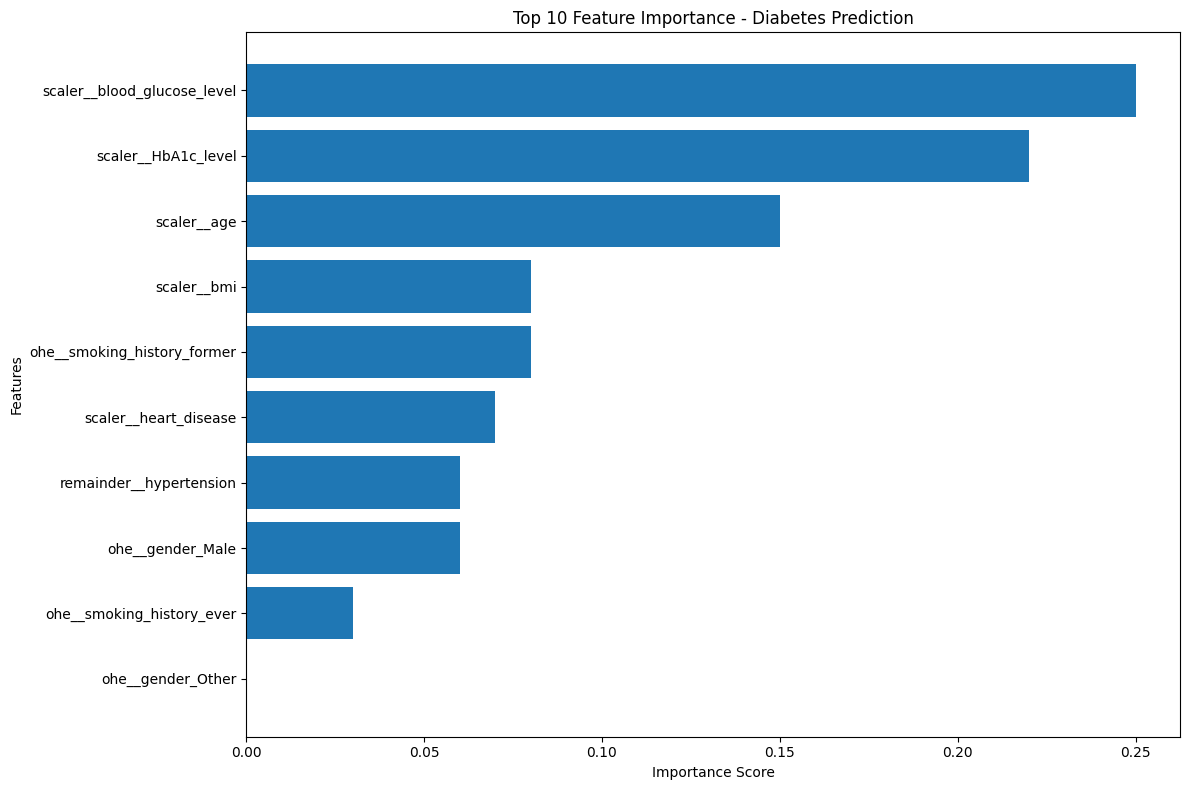

In [ ]:

# Best model from GridSearchCV
rf_model = grid.best_estimator_.named_steps['rf']

# Feature names after OneHotEncoding
feature_names = grid.best_estimator_.named_steps['tf'].get_feature_names_out()


# Importance values
importances = rf_model.feature_importances_

# DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort descending
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 features
top10 = importance_df.head(10)

# Plot
plt.figure(figsize=(12,8))
plt.barh(top10['Feature'], top10['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance - Diabetes Prediction")
plt.tight_layout()
plt.show()

array([[17327,   182],
       [  521,  1200]])

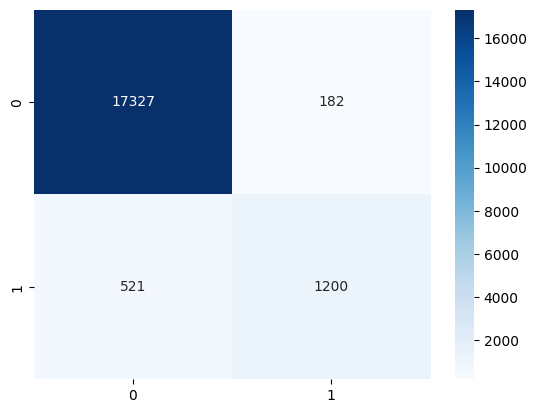

In [624]:
conf_matrix = confusion_matrix(y_test, grid.predict(x_test))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
conf_matrix

In [625]:
y_pred = grid.predict(x_test)
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17509
           1       0.87      0.70      0.77      1721

    accuracy                           0.96     19230
   macro avg       0.92      0.84      0.88     19230
weighted avg       0.96      0.96      0.96     19230

Accuracy: 96.3442537701508


In [626]:
# grid.best_params_

In [627]:
prob = grid.predict_proba(x_test[0:5])   

In [628]:
from sklearn.model_selection import cross_val_score

In [629]:
scores = cross_val_score(
    grid,      
    x_test,         # features
    y_test,         # target
    cv=5,     # 10-fold cross validation
    scoring='accuracy'
)

print(scores)
print("Mean Accuracy:", scores.mean())

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(


[0.94071763 0.96775871 0.91315653 0.94461778 0.94617785]
Mean Accuracy: 0.9424856994279771


In [632]:
import pickle   

with open('diabetes_rf_model.pkl', 'wb') as f:
    pickle.dump(grid, f)